In [1]:
import numpy as np

In [180]:
###
from ael_satellite_tools.preprocess import Earthcare
## prepare enviromnent
path = []
data_path = '/data/C.jerryjerry9/EarthCARE'
lat = [15,40]
lon = [110,150]
earthcare = Earthcare(work_path=[], lat_range=lat, lon_range=lon, 
                      sftp_username='Account', sftp_password = 'password')

import himawari_plotting
data_path = '/data/C.jerryjerry9/Himawari'
sub_domain_data_folder = 'example_data'
hima_plot = himawari_plotting.Himawari(work_path=[],sub_domain_data_folder=sub_domain_data_folder,
                                       data_path=data_path,plotting_lat_range=lat,plotting_lon_range=lon)
####

In [185]:
print(earthcare.lat_range)
print(earthcare.lon_range)
print(earthcare.data_path)

[15, 40]
[110, 150]
/data/C.jerryjerry9/EarthCARE


In [186]:
earthcare.information(product_list=True)

EarthCARE
onboard sensor: Cloud Profiling Radar (CPR)
                Atmospheric Lidar (ATLID)
                Multi-Spectral Imager (MSI)
                Broad-band Radiometer (BBR)
Current module foucs on atmosphere profiling data
CPR, ATLID, 2B-CPR-ATLID are involed
---------------------------------------------------
CPR & ATLID product
ESA Product
[CPR]         2A.CPR_CD;  2A.CPR_CLD; 2A.CPR_FMR;                 
              2A.CPR_TC
[ATLID]       2A.ATL_AER; 2A.ATL_ALD; 2A.ATL_CTH;                 
              2A.ATL_EBD; 2A.ATL_FM;  2A.ATL_ICE;                 
              2A.ATL_TC
[CPR + ATLID] 2B.AC_TC
---------------------------------------------------
JAXA Product
[CPR]         2A.CPR_ECO; 2A.CPR_CLP
[ATLID]       2A.ATL_CLA
[CPR + ATLID] 2B.AC_CLP
---------------------------------------------------
ESA Product descriptions:
https://earthcarehandbook.earth.esa.int/catalogue/index
JAXA Product descriptions:
https://www.eorc.jaxa.jp/EARTHCARE/data/L2prd_list_std_e.html

In [187]:
time_period = ['2026/03/01 0000','2026/04/01 0000']
product_name = ['2A.CPR_FMR']
### download data only depending on the lat range 
#earthcare.download_data(product_name,time_period)

In [188]:
time_period = ['2026/03/03 00','2026/03/03 23']
product_name = ['2A.CPR_FMR']
### collect file list on local server
cpr_full_list = earthcare.generate_list(product_name,time_period)
###
#target_lon_range = [110,150]
#target_lat_range = [10,50]
#cpr_list = earthcare.generate_sub_domain(product_name,time_period,target_lon_range,target_lat_range,mask_output=False)

2026030300 2026030323


In [189]:
len(cpr_full_list)

58

In [190]:
product_name = ['2A.CPR_CD']
dp_full_list = earthcare.generate_list(product_name,time_period)

2026030300 2026030323


In [191]:
var_list = earthcare.var_info(cpr_full_list,'reflectivity_corrected')

<class 'netCDF4.Variable'>
float32 reflectivity_corrected(along_track, CPR_height)
    long_name: Reflectivity corrected for gaseous attenuation
    units: dBZ
    _FillValue: 9.96921e+36
    radar_calibration_level_2a: 9.96921e+36
path = /ScienceData
unlimited dimensions: 
current shape = (4897, 218)
filling on


read variable: ['longitude']
read variable: ['latitude']
Check EarthCARE track pass the traget domain
read variable: ['time']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['longitude']
read variable: ['latitude']


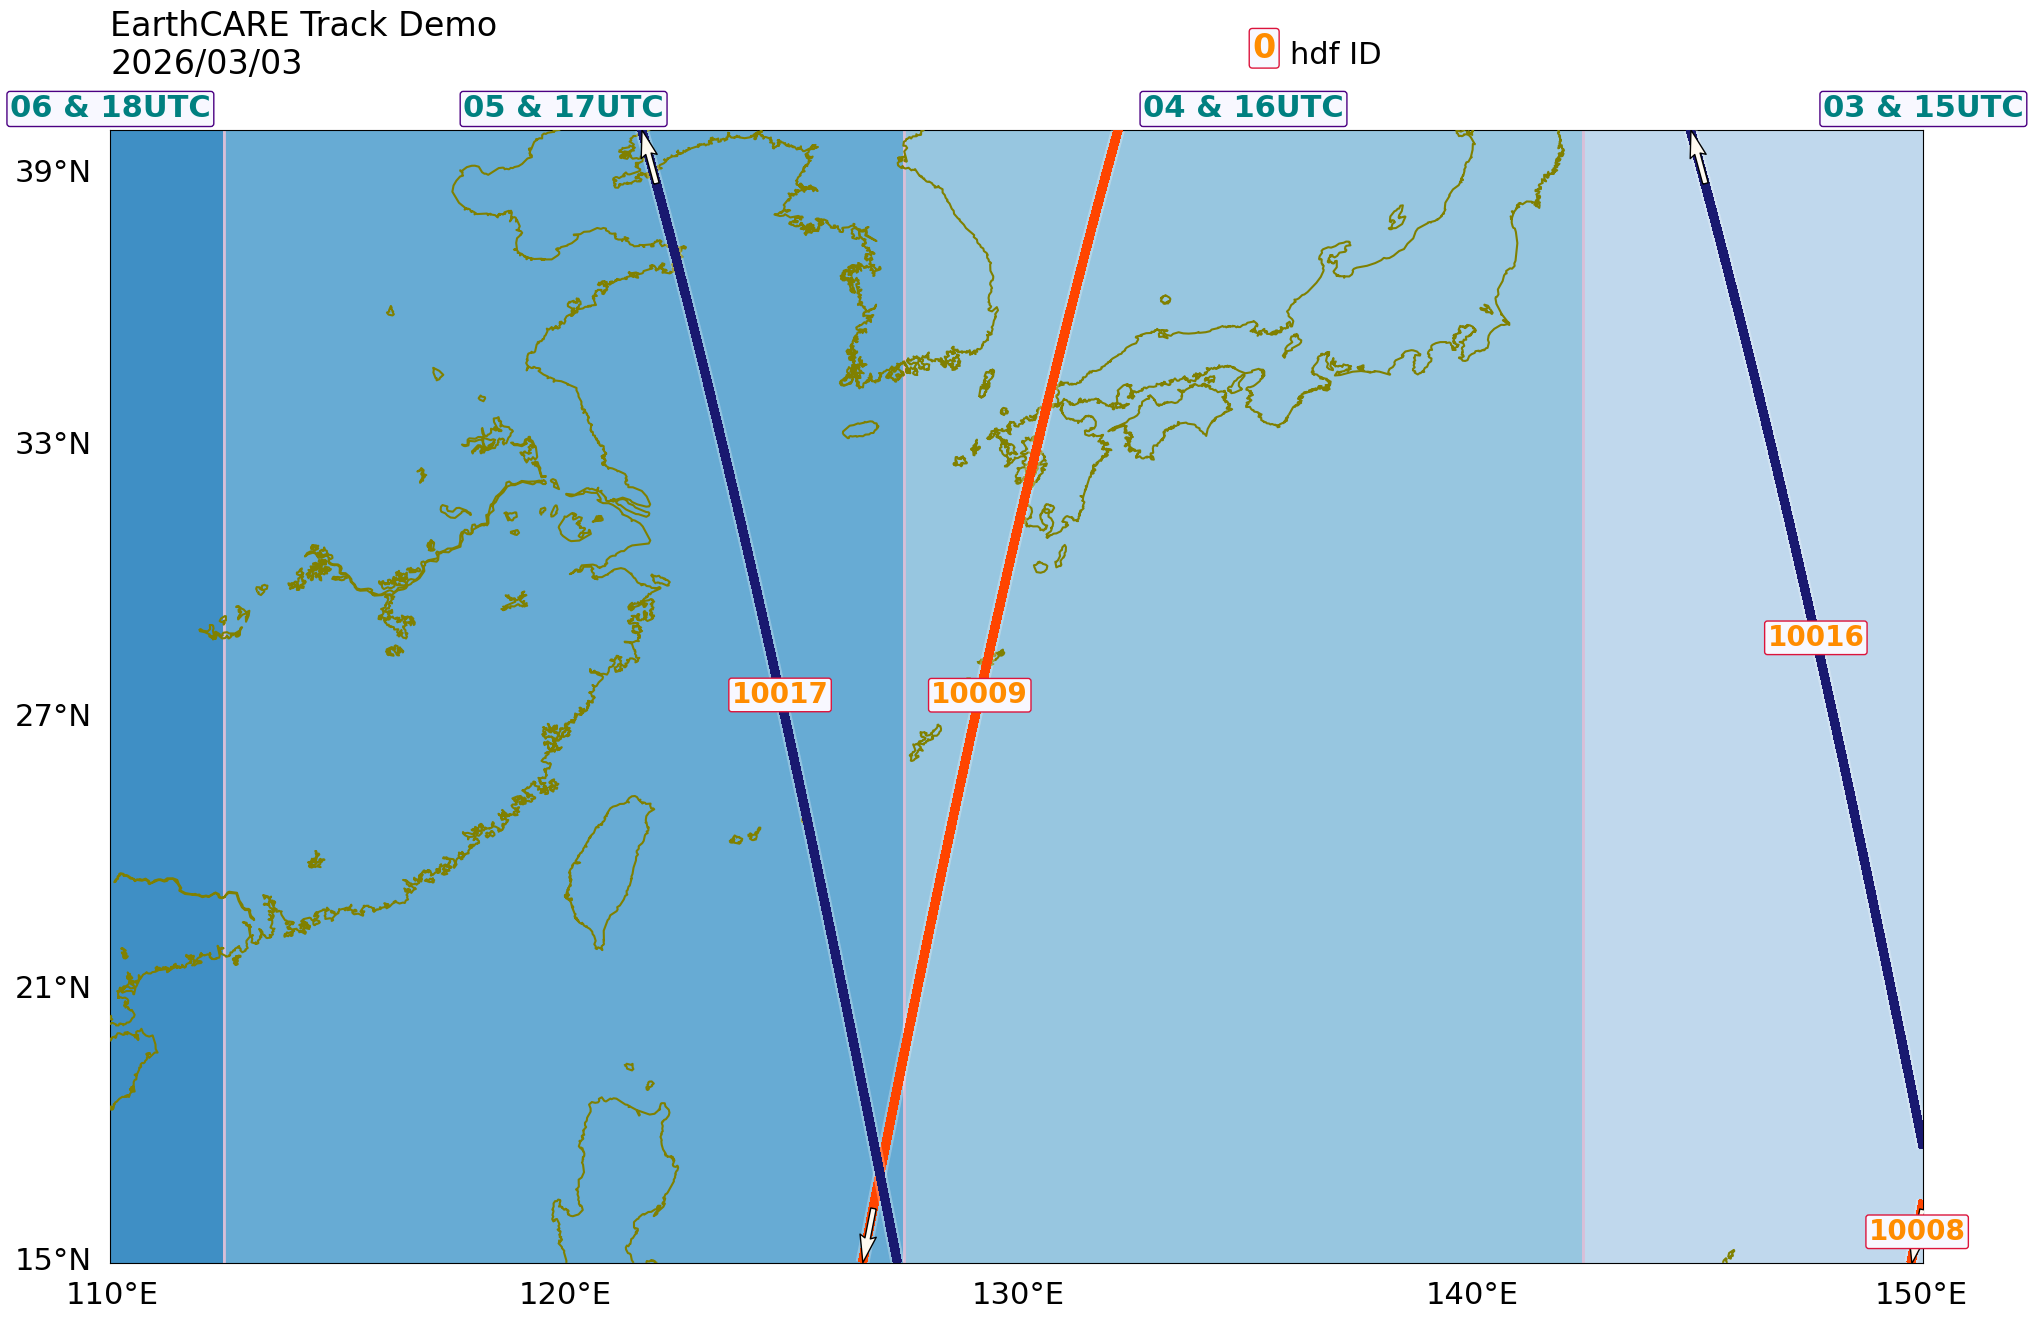

In [192]:
ax1 = earthcare.plot_track(cpr_full_list,
                           coast_line_color='olive',coast_line_width=1.5,coast_res='i',
                           lonlat_step=5,font_size=24,
                           loc='left',pad=40,figure_title='EarthCARE Track Demo',
                           prefix='earthcare_track_demo',
                           figure_name=[],figure_path=[], dpi=300,
                           track_color_method=None,
                           track_shadow=True,track_dir=True,
                           track_dir_pos='edge',arrow_len_scale = 0.065,
                           id_label=True,granule_label=True,date_label=False,
                           utc_label=True,night_time_label=True,timezone_gradient=True, 
                           save_fig=True)

In [120]:
### match file list across different product
#earthcare.cross_product_match(cpr_full_list,dp_full_list)
### read without any modify
#test_ref = earthcare.read_ori_data(cpr_full_list,'reflectivity_corrected')

In [193]:
### generate file list denpending lat lon region
### Use given target_lonlat_range first
### if there is no target_lonlat_range, use the default setting
target_lat_range = [20, 28]
target_lon_range = [110, 140]
extracted_files,extracted_mask = earthcare.sub_domain_check(cpr_full_list,
                                                            target_lon_range,target_lat_range,
                                                            mask_output=True)
#time_period = ['2026/03/02 00','2026/03/02 23']
#product_name = ['2A.CPR_FMR']
#extracted_files,extracted_mask = earthcare.generate_sub_domain(product_name,time_period,
#                                                               target_lon_range,target_lat_range,
#                                                               mask_output=True)
#### geometric_info for plotting
extracted_lon, extracted_lat,\
extracted_h5_date, extracted_h5_id, extracted_h5_granule,\
extracted_region_start_time,extracted_region_end_time \
                  = earthcare.read_geometric_info(extracted_files,
                                                  extracted_mask,lonlat_info=True)
####

read variable: ['longitude']
read variable: ['latitude']
Check EarthCARE track pass the traget domain
read variable: ['time']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['longitude']
read variable: ['latitude']


In [194]:
len(extracted_files)

4

In [195]:
time_period = ['2026/03/03 00','2026/03/03 23']
hima_time_delta = ['days=0','hours=1','minutes=0']

In [205]:
time_list = hima_plot.generate_time_list(time_period=time_period,time_delta=hima_time_delta)
file_list, full_path_file_list, avaiable_time_list = hima_plot.generate_data_list(time_list,AHI_band=[14],
                                                              check_data=True)
file_num = 6
band_data,plotting_lon_list,plotting_lat_list,output_file_list = hima_plot.read_nc_file(full_path_file_list[6])

read file:/data/C.jerryjerry9/Himawari/example_data/2026/03/03/202603030600_band_14.nc


read variable: ['longitude']
read variable: ['latitude']
Check EarthCARE track pass the traget domain
read variable: ['time']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['longitude']
read variable: ['latitude']


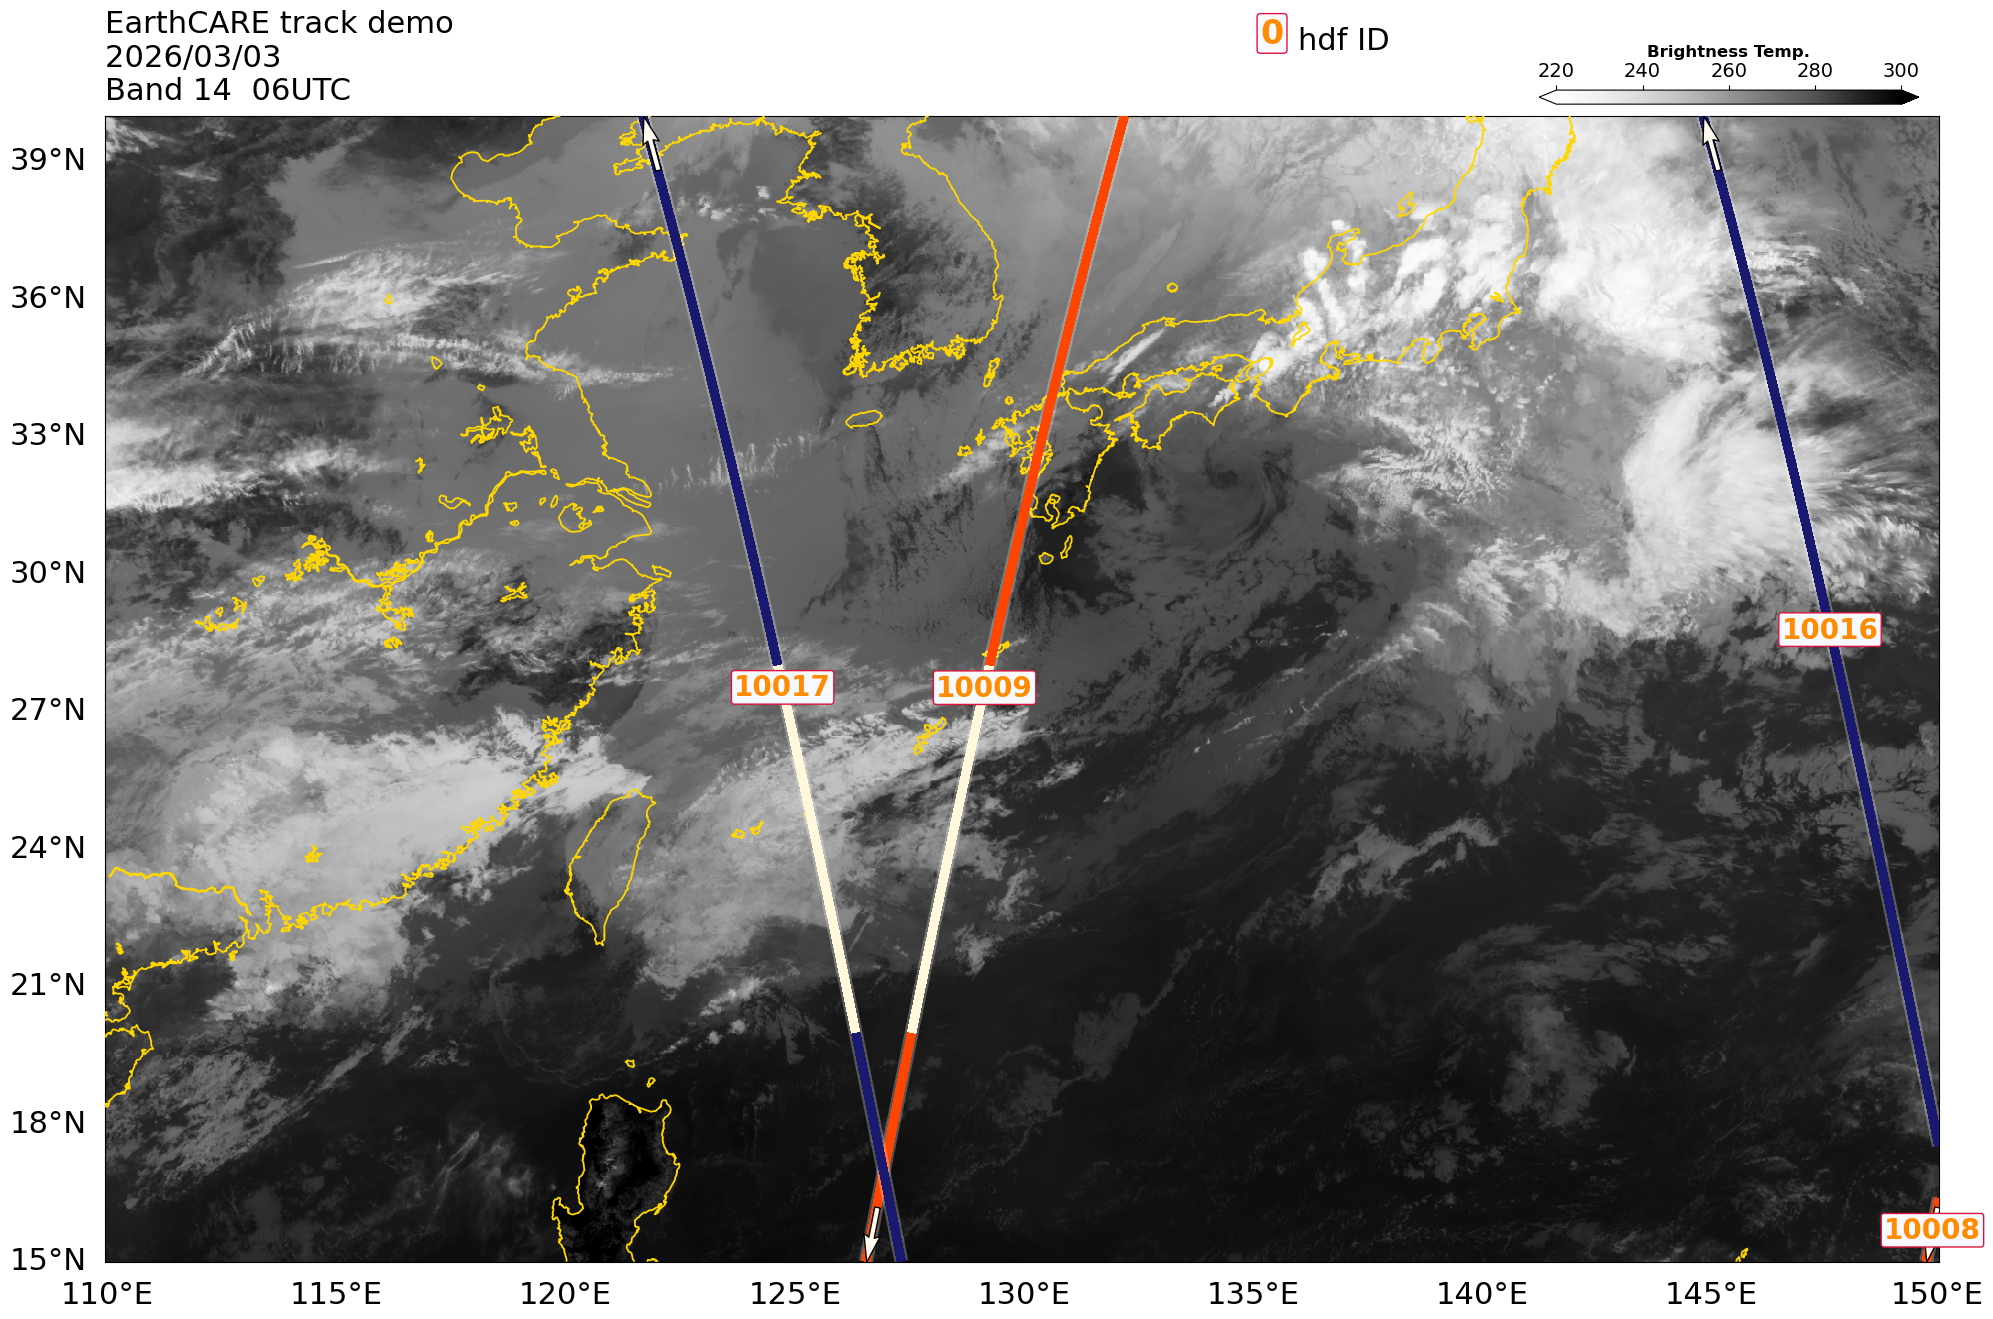

In [206]:
earthcare.plot_track_w_band(cpr_full_list,
                            band_data[0],plotting_lon_list[0],plotting_lat_list[0],
                            extracted_lon=extracted_lon,extracted_lat=extracted_lat,
                            tbb_range = [220,300], tbb_cmap = 'Greys',
                            track_color = None,extracted_track_color='cornsilk',
                            track_shadow=True, track_dir=True,
                            track_dir_pos='edge',arrow_len_scale = 0.065,
                            coast_line_color='gold',
                            lonlat_c='w',lonlat_width=0.1,lonlat_order=1,lonlat_step=8,font_size=24,
                            figure_title='EarthCARE track demo',band_product='Band 14 ',band_time=f'{avaiable_time_list[file_num][-4:-2]}UTC',
                            band_colorbar=True,
                            granule_label=True,id_label=True,date_label=False,
                            save_fig=False)

read variable: ['longitude']
read variable: ['latitude']
Check EarthCARE track pass the traget domain
read variable: ['time']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['longitude']
read variable: ['latitude']
read variable: ['reflectivity_corrected']
read variable: ['latitude']
read variable: ['height']
read variable: ['latitude']
read variable: ['surface_elevation']
read variable: ['latitude']
read variable: ['land_flag']
read variable: ['latitude']
read variable: ['time']
read variable: ['latitude']


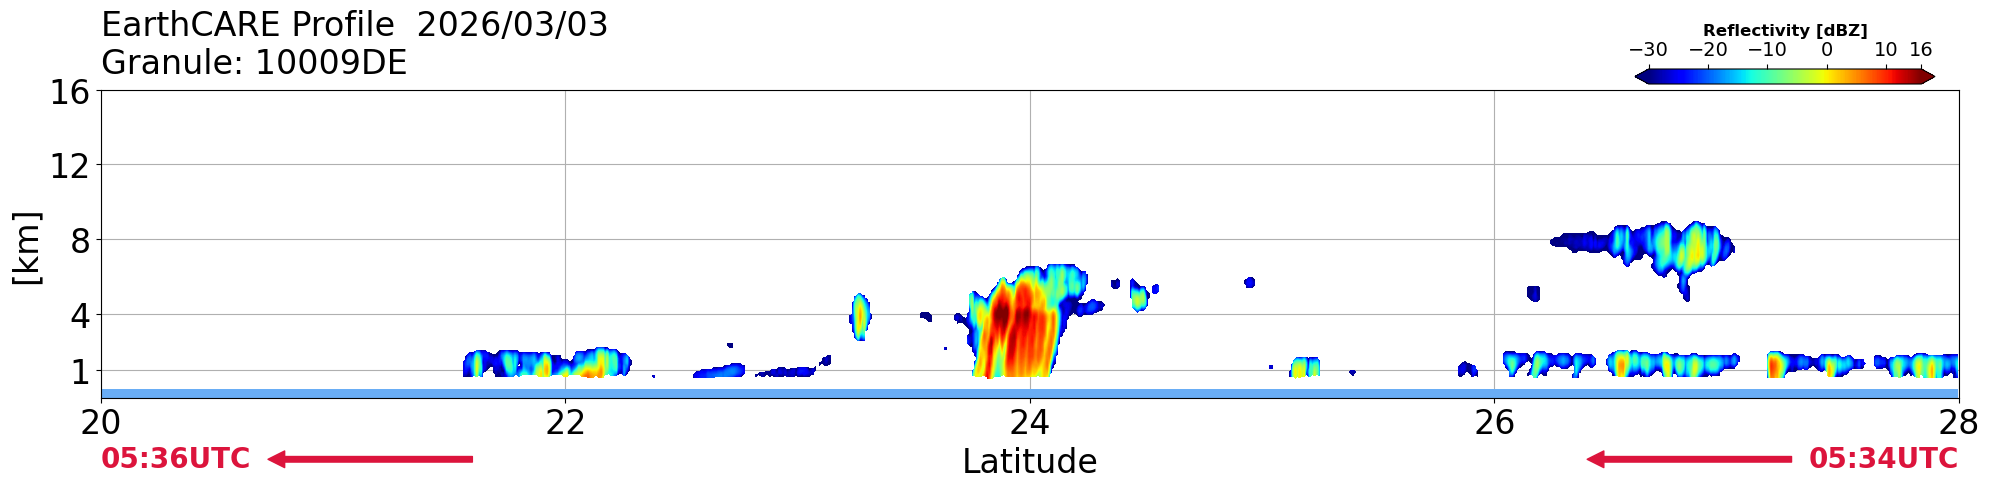

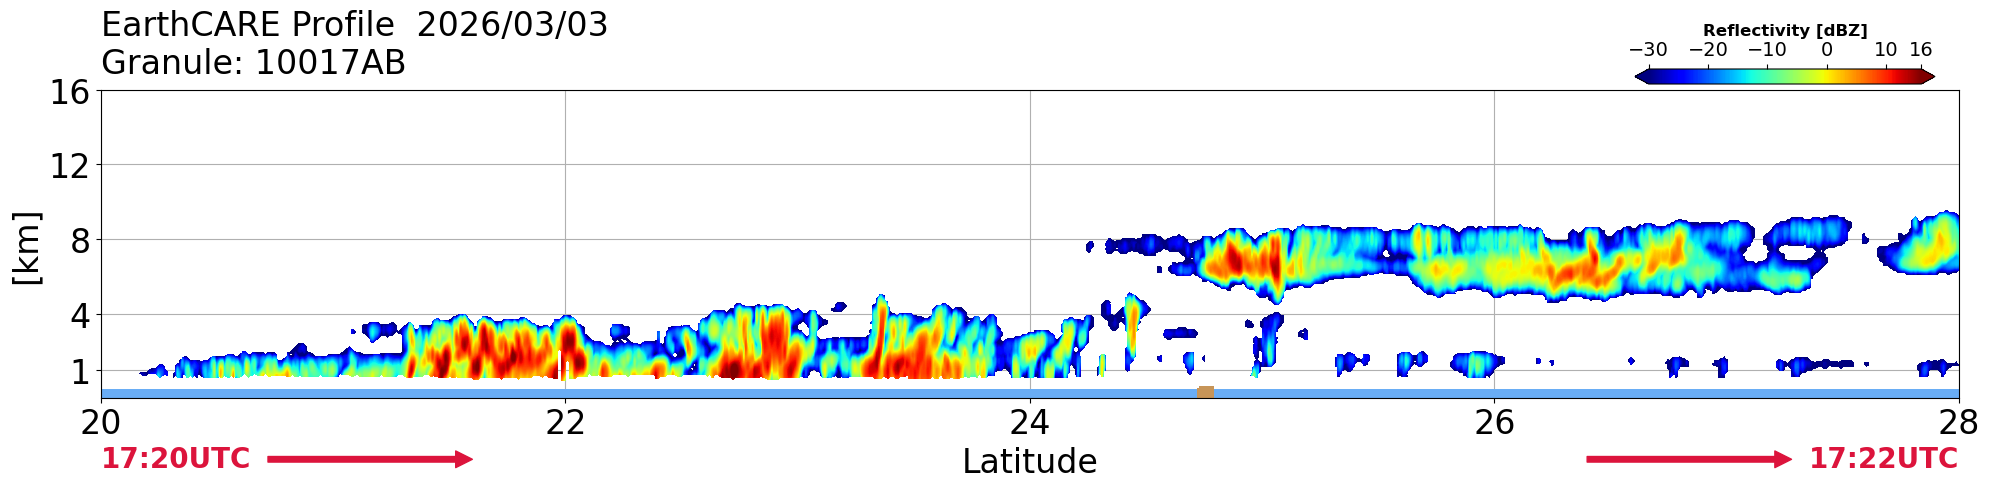

In [123]:
earthcare.ref_profile_demo(extracted_files,target_lon_range,target_lat_range,'contourf',
                           ### axis setting
                           x_axis_type = 'lat',x_step=5,
                           height_range=[-0.5,16],height_step=5,hei_size=5,
                           ### color bar
                           color_map='jet',value_range=[-30, 16],
                           bar_pos=3,bar_ticks=[-30,-20,-10,0,10,16],bar_label='Reflectivity [dBZ]',
                           ### fig info
                           y_label='[km]',
                           figure_title='EarthCARE Profile',
                           colorbar_plot=True,
                           time_dir=True,
                           ### read data setting
                           combine_same_track=True,
                           ### save fig
                           prefix='earthcare_profile',figure_name=[],
                           figure_path='earthcare_fig',dpi=300,save_fig=True)

In [124]:
"""
Merge function for read EarthCARE data
1. Cut target region data
2. Shift longitude from -180 ~ 180 to 0 ~ 360 ("fit_era5_lon" switch)
3. Combine same track data (if target region cross different frames)
"""
combine_track = True
### taget var
combined_granule, combined_va = earthcare.read_data(extracted_files,'reflectivity_corrected', extracted_mask, 
                                                    combine_same_track=True,skip_margin=True,fit_era5_lon=True,granule_out=True)
### y-axis
combined_height = earthcare.read_data(extracted_files,'height', extracted_mask, combine_same_track=combine_track,granule_out=False)
### land sea
combined_elev = earthcare.read_data(extracted_files,'surface_elevation', extracted_mask, combine_same_track=combine_track,granule_out=False)
combined_landsea = earthcare.read_data(extracted_files,'land_flag', extracted_mask, combine_same_track=combine_track,granule_out=False)

### lat lon
combined_lat = earthcare.read_data(extracted_files,'latitude', extracted_mask, combine_same_track=combine_track,granule_out=False)
combined_lon = earthcare.read_data(extracted_files,'longitude', extracted_mask, combine_same_track=combine_track,granule_out=False)

read variable: ['reflectivity_corrected']
read variable: ['latitude']
read variable: ['height']
read variable: ['latitude']
read variable: ['surface_elevation']
read variable: ['latitude']
read variable: ['land_flag']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['longitude']
read variable: ['latitude']


In [126]:
file_num = 1
combined_va[file_num][combined_va[file_num]>1000000] = np.nan

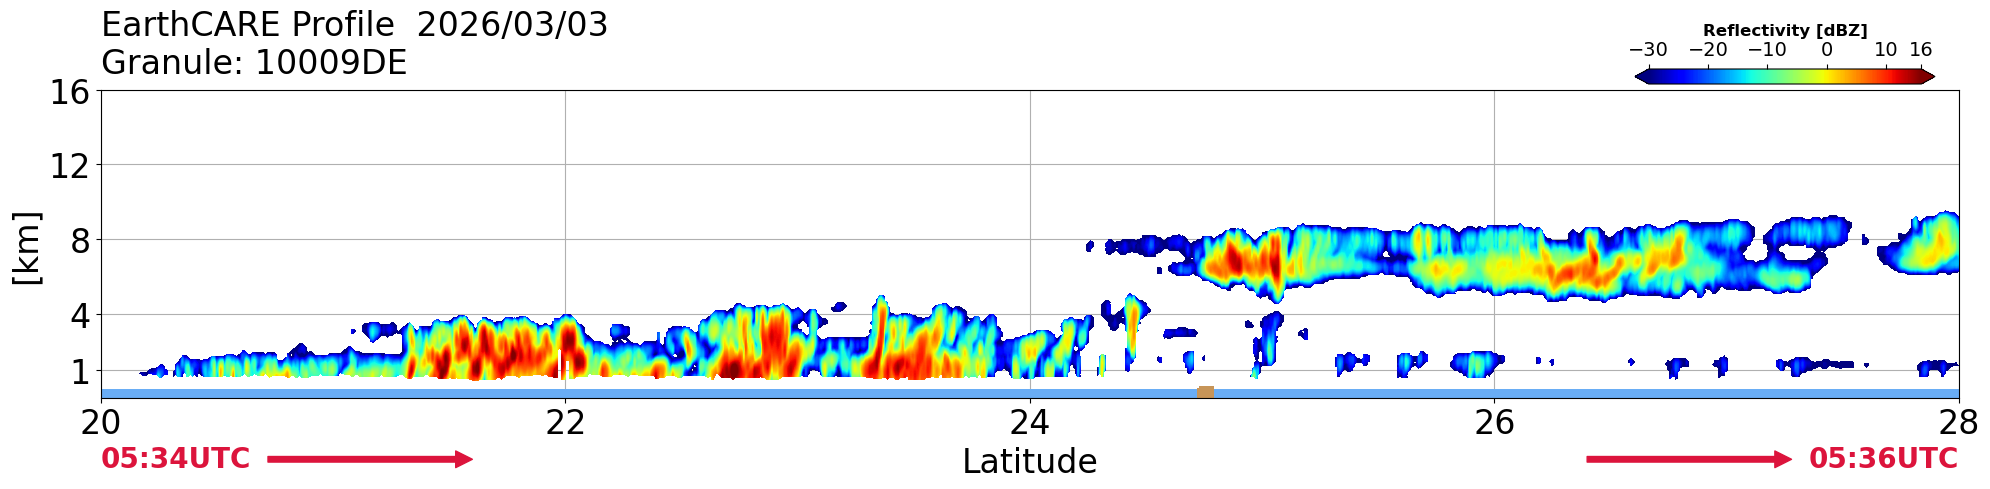

In [127]:
fig,ax1 = earthcare.plot_landsea_base(combined_elev[file_num],combined_landsea[file_num],combined_height[file_num],
                                      combined_lat[file_num],hei_size=5)
earthcare.plot_profile(combined_va[file_num],'contourf',
                       ### axis setting
                       x_axis=combined_lat[file_num],x_step=5,
                       extracted_hei=combined_height[0],height_range=[-0.5,16],height_step=5,
                       ### 
                       hei_size=5,fig_id=fig,axis=ax1,
                       ### color map
                       color_map='jet',value_range=[-30, 16],
                       bar_pos=3,bar_ticks=[-30,-20,-10,0,10,16],bar_label='Reflectivity [dBZ]',
                       ### fig info
                       hdf_date=extracted_h5_date[0],hdf_granule=extracted_h5_granule[0],
                       region_start_time=extracted_region_start_time[0],
                       region_end_time=extracted_region_end_time[0],
                       x_label='Latitude',y_label='[km]',
                       figure_title='EarthCARE Profile',
                       ### save fig
                       prefix='earthcare_prof',figure_path='earthcare_fig',dpi=300,
                       plot_height_adjust=True,
                       start_plot=False,finish_plot=True,time_dir=True,save_fig=False)

In [128]:
######################
###Doppler velocity###
######################

In [129]:
var_list = earthcare.var_info(dp_full_list,'doppler_velocity_best_estimate')

<class 'netCDF4.Variable'>
float32 doppler_velocity_best_estimate(along_track, CPR_height)
    long_name: Doppler velocity best estimate
    units: m s-1
    comment: Unfolded integrated Doppler velocity
    _FillValue: 9.96921e+36
path = /ScienceData
unlimited dimensions: 
current shape = (4897, 218)
filling on


In [134]:
#time_period = ['2026/03/03 00','2026/03/03 23']
product_name = ['2A.CPR_CD']
extracted_dp_files,extracted_dp_mask = earthcare.generate_sub_domain(product_name,time_period,
                                                               target_lon_range,target_lat_range,
                                                               mask_output=True)

2026030300 2026030323
read variable: ['longitude']
read variable: ['latitude']
Check EarthCARE track pass the traget domain


In [135]:
combine_track = True
### taget var
combined_granule, combined_va = earthcare.read_data(extracted_dp_files,'doppler_velocity_best_estimate', extracted_dp_mask, 
                                                    combine_same_track=True,skip_margin=True,fit_era5_lon=True,granule_out=True)
### y-axis
combined_height = earthcare.read_data(extracted_dp_files,'height', extracted_dp_mask, combine_same_track=combine_track,granule_out=False)
### land sea
combined_elev = earthcare.read_data(extracted_dp_files,'surface_elevation', extracted_dp_mask, combine_same_track=combine_track,granule_out=False)
combined_landsea = earthcare.read_data(extracted_dp_files,'land_flag', extracted_dp_mask, combine_same_track=combine_track,granule_out=False)

### lat lon
combined_lat = earthcare.read_data(extracted_dp_files,'latitude', extracted_dp_mask, combine_same_track=combine_track,granule_out=False)
combined_lon = earthcare.read_data(extracted_dp_files,'longitude', extracted_dp_mask, combine_same_track=combine_track,granule_out=False)

read variable: ['doppler_velocity_best_estimate']
read variable: ['latitude']
read variable: ['height']
read variable: ['latitude']
read variable: ['surface_elevation']
read variable: ['latitude']
read variable: ['land_flag']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['latitude']
read variable: ['longitude']
read variable: ['latitude']


In [136]:
file_num = 1
combined_va[file_num][combined_va[file_num]>1000000] = np.nan

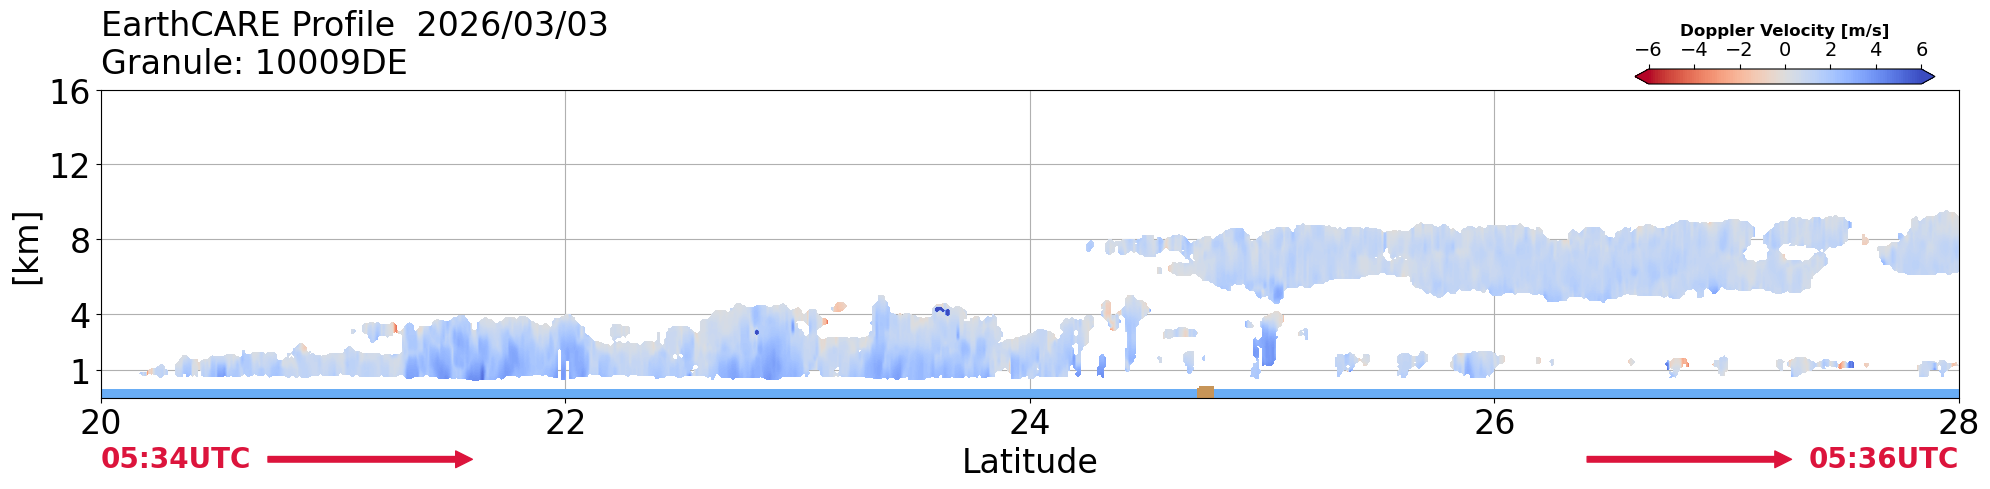

In [137]:
fig,ax1 = earthcare.plot_landsea_base(combined_elev[file_num],combined_landsea[file_num],combined_height[file_num],
                                      combined_lat[file_num],hei_size=5)
earthcare.plot_profile(combined_va[file_num],'contourf',
                       ### axis setting
                       x_axis=combined_lat[file_num],x_step=5,
                       extracted_hei=combined_height[0],height_range=[-0.5,16],height_step=5,
                       ### 
                       hei_size=5,fig_id=fig,axis=ax1,
                       ### color map
                       color_map='coolwarm_r',value_range=[-6, 6],
                       bar_pos=3,bar_ticks=[-6,-4,-2,0,2,4,6],bar_label='Doppler Velocity [m/s]',
                       ### fig info
                       hdf_date=extracted_h5_date[0],hdf_granule=extracted_h5_granule[0],
                       region_start_time=extracted_region_start_time[0],
                       region_end_time=extracted_region_end_time[0],
                       x_label='Latitude',y_label='[km]',
                       figure_title='EarthCARE Profile',
                       ### save fig
                       prefix='earthcare_prof',figure_path='earthcare_fig',dpi=300,
                       plot_height_adjust=True,
                       start_plot=False,finish_plot=True,time_dir=True,save_fig=False)

In [ ]:
earthcare.read_ori_data(full_path_file_list,var_name,skip_margin=True)